In [1]:
import pandas as pd

In [2]:
from homework05 import (
    exercise_1_fama_french, 
    exercise_2_bootstrap_once, 
    exercise_3_bootstrap_pvalues,
    exercise_4_block_bootstrap_pvalues, 
    exercise_5_block_bootstrap_ci
)

**IMPORTANT**

We will use the log excess returns in the following!

In [3]:
df_raw = pd.read_csv("./s5_data.txt", sep="\t")
df_raw.head()

,date,fund1,fund2,fund3,fund4,fund5,fund1_qoq,fund2_qoq,fund3_qoq,fund4_qoq,fund5_qoq,mktrf,smb,hml,rf,mktrf_qoq,smb_qoq,hml_qoq,rf_qoq
0,1990-02-28,1.89,NaN,NaN,-0.18,2.14,-1.645038,NaN,NaN,0.269693,10.951563,1.11,1.03,0.61,0.57,-5.746330,-2.666841,1.779672,1.760223
1,1990-03-31,5.95,NaN,NaN,0.29,-0.16,3.472428,NaN,NaN,0.319708,5.882279,1.83,1.52,-2.89,0.64,-5.122072,1.252816,-1.457389,1.790566
2,1990-04-30,-0.73,NaN,NaN,-0.34,2.07,7.164402,NaN,NaN,-0.230894,4.087491,-3.36,-0.50,-2.55,0.69,-0.499154,2.052828,-4.789039,1.912022
3,1990-05-31,2.00,NaN,NaN,-1.78,0.28,7.280096,NaN,NaN,-1.830078,2.192027,8.42,-2.56,-3.73,0.68,6.694509,-1.573517,-8.896142,2.023490
4,1990-06-30,0.99,NaN,NaN,-0.66,2.45,2.257828,NaN,NaN,-2.759996,4.863513,-1.09,1.43,-1.95,0.63,3.635018,-1.660775,-8.014280,2.013353


## Exercise 1

**ATTENTION**

fund2_qoq contains NaN values!

In [4]:
ff_model = exercise_1_fama_french(df_raw)
ff_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     fund2_qoq_log_excess   R-squared:                       0.691
Model:                              OLS   Adj. R-squared:                  0.687
Method:                   Least Squares   F-statistic:                     157.3
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):           1.49e-53
Time:                          00:24:28   Log-Likelihood:                -580.97
No. Observations:                   215   AIC:                             1170.
Df Residuals:                       211   BIC:                             1183.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8393      0.262      3.208      0.002       0.324       1.355
mktrf_qoq      0.6629      0.034     19.357      0.000       0.595       0.730
smb_qoq        0.2231      0.044      5.095      0.000       0.137       0.309
hml_qoq        0.4228      0.043      9.806      0.000       0.338       0.508
==============================================================================
Omnibus:                        9.413   Durbin-Watson:                   0.630
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               10.613
Skew:                           0.381   Prob(JB):                      0.00496
Kurtosis:                       3.777   Cond. No.                         9.09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Exercise 2

In [5]:
ex2_results = exercise_2_bootstrap_once(df_raw)
ex2_results["bootstrap_coefficients"]

const        0.998147
mktrf_qoq    0.673954
smb_qoq      0.200973
hml_qoq      0.462444
dtype: float64

## Exercise 3

We define the null hypothesis as: 

$H_0: \beta_j = 0$

In [6]:
ex3_results = exercise_3_bootstrap_pvalues(df_raw, 10000)
ex3_results["bootstrap_pvalues_two_sided"]

const        0.0013
mktrf_qoq    0.0000
smb_qoq      0.0000
hml_qoq      0.0000
dtype: float64

## Exercise 4

**REMARK**

The homework asks for a **block bootstrap** using `tsboot()` from R’s **boot** package. Since we work in **Python**, we implemented the same idea manually as closely as possible.

Our implementation follows the **moving block bootstrap** logic behind `tsboot(..., sim = "fixed")`:

1. Estimate the original Fama-French regression by OLS.
2. Collect the fitted residual series $\hat{u}_t$.
3. Choose the block length as
   $$
   l = \lfloor T^{1/3} \rfloor,
   $$
   in line with the homework and TA script.
4. Construct **overlapping blocks** of consecutive residuals:
   $$
   (\hat{u}_1, \ldots, \hat{u}_l), \quad
   (\hat{u}_2, \ldots, \hat{u}_{l+1}), \quad \ldots
   $$
5. Resample these blocks **with replacement** until a bootstrap residual series $\hat{u}_t^*$ of length $T$ is obtained.
6. Form the artificial response
   $$
   y_t^* = \hat{y}_t + \hat{u}_t^*
   $$
   and re-estimate the regression.
7. Repeat this many times to obtain the bootstrap distribution of the coefficients.

This reproduces the main purpose of `tsboot()`: unlike standard residual resampling, it preserves the **local time dependence** and **autocorrelation structure** in the residuals by resampling **blocks of consecutive observations** rather than individual residuals.

In [7]:
ex4_results = exercise_4_block_bootstrap_pvalues(df_raw)
ex4_results["bootstrap_pvalues_two_sided"]

const        0.0625
mktrf_qoq    0.0000
smb_qoq      0.0002
hml_qoq      0.0000
dtype: float64

### Explanation Exercise 4

The block bootstrap preserves the serial dependence in the residuals, whereas the standard bootstrap resamples individual residuals as if they were iid and therefore breaks that dependence structure. Because positive autocorrelation reduces the effective amount of independent information, it increases the uncertainty of the coefficient estimates. As a result, the block bootstrap typically produces a wider bootstrap distribution and therefore higher p-values.

## Exercise 5

In [8]:
ex5_results = exercise_5_block_bootstrap_ci(df_raw)
ex5_results["confidence_intervals"]

,ci_lower,ci_upper
const,0.072993,1.549811
mktrf_qoq,0.581563,0.745341
smb_qoq,0.125996,0.320456
hml_qoq,0.317506,0.528744


### Switch of the dataset: We now move to: 's5 data panel hw.txt'

In [9]:
df_panel = pd.read_csv("./s5_data_panel_hw.txt", sep="\t")
df_panel.head()

,main_strategy,date,id,management_fee,incentive_fee,high_watermark,firm_id,strategy_code,performance,nav,assets,mktrf,smb,hml,rf
0,0,19920131,468,2.0,20.0,1.0,232.0,3,7.25,NaN,NaN,-0.59,8.45,4.50,0.34
1,0,19920229,468,2.0,20.0,1.0,232.0,3,-1.88,NaN,NaN,1.09,0.88,6.36,0.28
2,0,19920331,468,2.0,20.0,1.0,232.0,3,-2.98,NaN,NaN,-2.66,-1.03,3.66,0.34
3,0,19920430,468,2.0,20.0,1.0,232.0,3,-10.22,NaN,NaN,1.07,-6.12,4.28,0.32
4,0,19920531,468,2.0,20.0,1.0,232.0,3,-0.49,NaN,NaN,0.30,0.40,1.27,0.28


In [10]:
from homework05 import (
    exercise_6_boxplots, 
    exercise_7_pooled_ols, 
    exercise_8_durbin_watson_test, 
    exercise_9_pooled_ols_robust, 
    exercise_10_fixed_effects_robust, 
    exercise_11_recover_strategy_alphas
)

## Exercise 6

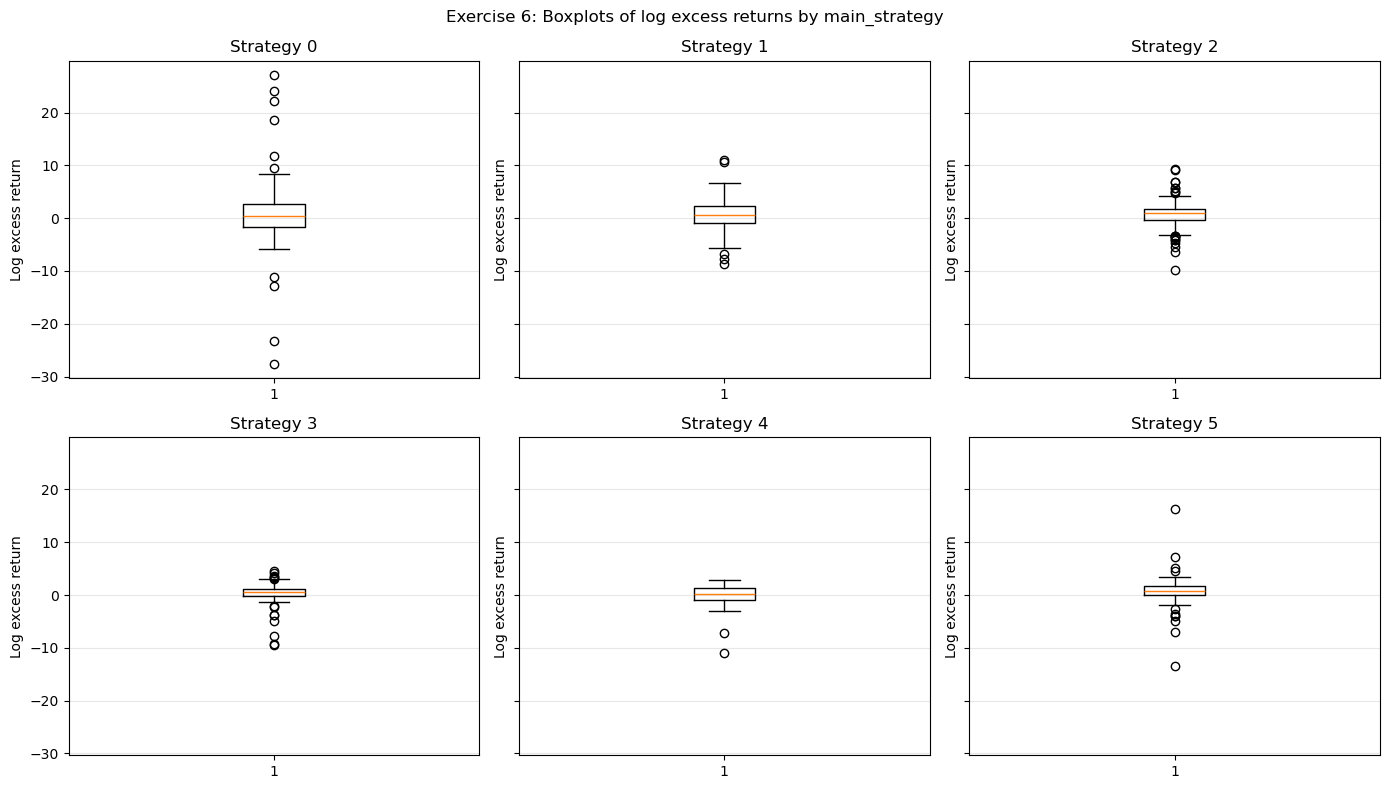

In [11]:
ex6_results = exercise_6_boxplots(df_panel)

## Exercise 7

For each coefficient $\beta_j$, the test is

$$
H_0:\ \beta_j = 0
\qquad \text{vs.} \qquad
H_1:\ \beta_j \neq 0
$$

So in your pooled OLS regression, this means

$$
H_0:\ \alpha = 0
$$

$$
H_0:\ \beta_{\mathrm{mktrf}} = 0
$$

$$
H_0:\ \beta_{\mathrm{smb}} = 0
$$

$$
H_0:\ \beta_{\mathrm{hml}} = 0
$$

with test statistic

$$
t = \frac{\hat{\beta}_j - 0}{\mathrm{SE}(\hat{\beta}_j)}.
$$

In [12]:
ex7_results = exercise_7_pooled_ols(df_panel)
ex7_results["summary_table"]

,coef_hat,std_error,t_stat,p_value
const,0.465964,0.082057,5.678565,1.705757e-08
mktrf,0.223646,0.018390,12.160955,3.715004e-32
smb,0.079805,0.024581,3.246528,1.200785e-03
hml,-0.015766,0.026435,-0.596424,5.510056e-01


### Explanation Exercise 7

The pooled OLS results suggest a positive and significant alpha, a strong positive exposure to the market factor, a smaller but still significant positive exposure to SMB and no significant exposure to HML. Since this is a pooled model, these coefficients are interpreted as common across all strategy groups.

**REMARK**: However, since we do a pooled OLS, we do not respect the eventual autocorrelation we might encounter in the residuals. We test this in Ex. 8

## Exercise 8

In [13]:
ex8_results = exercise_8_durbin_watson_test(df_panel)
ex8_results["summary_table"]

,durbin_watson_stat,implied_rho1,n_within_panel_lags,conclusion_rule_of_thumb
0,1.768889,0.115555,1188,no strong evidence of positive autocorrelation


Since Python has no exact pdwtest() equivalent in statsmodels, I computed the panel-aware Durbin-Watson statistic manually within each main_strategy. The resulting DW statistic is approximately 1.77, suggesting only mild positive autocorrelation and no strong evidence of problematic serial correlation by the usual rule of thumb.

## Exercise 9

In [14]:
ex9_results = exercise_9_pooled_ols_robust(df_panel)
ex9_results["summary_table"]

,coef_hat,std_error_ols,p_value_ols,std_error_robust,t_stat_robust,p_value_robust
const,0.465964,0.082057,1.705757e-08,0.103706,4.493137,0.004134
mktrf,0.223646,0.018390,3.715004e-32,0.020829,10.737263,0.000039
smb,0.079805,0.024581,1.200785e-03,0.026215,3.044202,0.022680
hml,-0.015766,0.026435,5.510056e-01,0.035862,-0.439634,0.675595


### Explanation Exercise 9
Exercise 9 shows that pooled OLS inference in Exercise 7 was too optimistic for at least one coefficient. After using robust standard errors, the standard errors increase. The intercept, market factor and SMB remain significant at the 5% level, but SMB becomes much weaker and is no longer significant at the 1% level. HML remains insignificant. This is exactly the lecture-notes point that panel regressions require careful handling of non-iid residuals when doing hypothesis tests.

## Exercise 10

In [15]:
ex10_results = exercise_10_fixed_effects_robust(df_panel)
ex10_results["summary_table"]

,coef_hat,std_error_fe,p_value_fe,std_error_robust,t_stat_robust,p_value_robust,significant_5pct_fe,significant_5pct_robust
mktrf_within,0.222737,0.018356,4.936162e-32,0.026264,8.480667,0.000375,True,True
smb_within,0.080104,0.024530,1.123643e-03,0.037834,2.117236,0.087813,True,False
hml_within,-0.016675,0.026386,5.275248e-01,0.017167,-0.971373,0.375975,False,False


### Explanation Exercise 10

Fixed effects lets each strategy have its own baseline alpha, removes all time-constant strategy heterogeneity by demeaning within strategy, and estimates the factor loadings only from within-strategy time variation; therefore no intercept appears in the transformed regression. 
This is bascially the same in the demenaed CAPM!

## Exercise 11

In [16]:
ex11_results = exercise_11_recover_strategy_alphas(df_panel)
ex11_results["summary_table"]

,rank,main_strategy,alpha_hat,y_bar,mktrf,smb,hml
0,1,5,0.671817,0.775172,0.431368,0.157895,0.322316
1,2,2,0.527952,0.656448,0.583007,0.049379,0.318856
2,3,1,0.488958,0.604921,0.497120,0.124800,0.285520
3,4,0,0.484179,0.592620,0.445972,0.209074,0.458241
4,5,3,0.279665,0.389475,0.441864,0.214972,0.349548
5,6,4,-0.151781,-0.137357,-0.006727,0.202182,0.016364
